# Crop Entropy from Government Statistics

The map-derived entropy in `data/crop_entropy/` inherits the crop map's error, which
varies widely by state (`agreement_Rice` ranges roughly 0.24–0.98). This notebook
recomputes crop entropy directly from the **DES district area statistics** and checks
whether the two agree.

Covers **30 individual crops** in Kharif — cereals, pulses, oilseeds and commercial
crops (cotton, sugarcane, jute, tobacco).

**Shannon entropy** over sown-area shares:

$$H = -\sum_i p_i \ln p_i, \qquad p_i = \frac{\text{area}_i}{\sum_j \text{area}_j}$$

Outputs written to `../../data/`:
- `census_crop_entropy_district.csv`
- `census_crop_entropy_state.csv`


In [1]:
import glob, re, os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

DATA = '../../data'
pd.set_option('display.width', 150)

SEASON = 'Kharif'      # matches the kharif GCVI analysis; 'Total' for annual

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Crop baskets

"Crop basket" = **which set of crops an entropy measure counts**. Entropy is entirely
determined by this list, so the same district gives a different number under a different
basket. Three are used in this notebook:

| # | Basket | Source | Crops |
|---|---|---|---|
| 1 | **DES census** | `data/yield/DES-District-Data-For-*.csv` | 30 individual Kharif crops |
| 2 | **Crop map** | Jordi `crop_map_<State>` GEE asset | 5 mapped classes |
| 3 | **DES, map basket** | `data/yield/DES-*.csv` | DES Kharif, restricted to the map's crops |

Basket 3 is the **control**. Baskets 1 and 2 differ in *two* ways at once — crop list and
data source — so a disagreement between them is ambiguous. Basket 3 uses the same source and season as
basket 1 but the map's crop list, so **B1 vs B3 varies only the crop list** and
**B3 vs B2 varies only the source**.

The Jordi asset is a single `classification` band with six values (0–5): the **five
mapped crops plus one non-crop class** (forest / other land). It carries no class-name
metadata, so the basket-2 names below come from the `pred_*_ha` / `census_*_ha` columns
of `district_agreement_for_gee.csv`.

> ⚠ The **value → crop-name mapping is still unverified**. The GCVI pipeline masks on
> `.eq(2)`, and class 2 covers 72% of Punjab — very close to Punjab's actual kharif rice
> share (~74% of net sown area) — which suggests **class 2 is rice specifically**, not
> "any cropland". If so, the mask labelled "Crop mask" throughout the GCVI analysis is
> really a *rice* mask. Worth confirming before writing up.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CROP BASKETS — which crops each entropy measure counts
# ═══════════════════════════════════════════════════════════════════════════

# ── Basket 1: DES census (Kharif) ─────────────────────────────────────────
#    30 individual crops. Groups are for documentation/inspection only —
#    entropy is computed over all of them pooled, not per group.
DES_BASKET = {
    'cereals':    ['Rice', 'Wheat', 'Maize', 'Bajra', 'Jowar', 'Ragi',
                   'Small Millets', 'Barley'],
    'pulses':     ['Gram', 'Tur', 'Moong', 'Urad', 'Lentil', 'Other Pulses'],
    'oilseeds':   ['Groundnut', 'Soybean', 'Rapeseed & Mustard', 'Sesamum',
                   'Sunflower', 'Safflower', 'Castorseed', 'Linseed', 'Nigerseed'],
    'commercial': ['Cotton', 'Sugarcane', 'Jute', 'Mesta', 'Tobacco',
                   'Guarseed', 'Sannhemp'],
}
DES_CROPS = sorted({c for v in DES_BASKET.values() for c in v})

# ── Basket 2: the crop map's classes ──────────────────────────────────────
#    The raster has SIX values (0-5) = these 5 crops + 1 non-crop class
#    (forest / other land). Names below come from the census_*/pred_* columns of
#    district_agreement_for_gee.csv, not from the raster (it has no class-name
#    metadata), so the value -> crop mapping is UNVERIFIED.
#    The GCVI pipeline masks on .eq(2); class 2 is ~72% of Punjab, matching its
#    kharif rice share, so class 2 is probably RICE rather than generic cropland.
MAP_BASKET   = ['Rice', 'Maize', 'Peas', 'Cotton', 'Sugarcane']
MAP_N_CLASSES = 6          # 5 crops + non-crop
MAP_MASK_VALUE = 2         # value used by the GCVI pipeline's crop mask

# ── Basket 3: census areas restricted to the map's basket (the control) ───
CONTROL_BASKET = MAP_BASKET

# ── aggregate rows in the DES 'Crop' column: SUMS of other rows ────────────
#    Including them would double-count every district (verified in section 2).
AGGREGATES = {
    'Total Food Grains', 'Cereals', 'Total Pulses',
    'Nutri/Coarse Cereals', 'Shree Anna /Nutri Cereals',
    'Total Oil Seeds',          # added with the oilseed/commercial-crop data
    'Jute & Mesta',             # = Jute + Mesta, verified below
}
# 'Other Pulses' is a genuine residual bucket, so it is KEPT as one category.

print(f"Basket 1  DES census   : {len(DES_CROPS)} crops")
for g, cs in DES_BASKET.items():
    print(f"            {g:<11} ({len(cs)}): {', '.join(cs)}")
print(f"\nBasket 2  crop map     : {len(MAP_BASKET)} classes -> {', '.join(MAP_BASKET)}")
print(f"Basket 3  census/map   : {len(CONTROL_BASKET)} (same names, census areas)")
print(f"\noverlap 1 n 2 : {sorted(set(MAP_BASKET) & set(DES_CROPS))}")
print(f"in 2 not in 1 : {sorted(set(MAP_BASKET) - set(DES_CROPS))}")

Basket 1  DES census   : 30 crops
            cereals     (8): Rice, Wheat, Maize, Bajra, Jowar, Ragi, Small Millets, Barley
            pulses      (6): Gram, Tur, Moong, Urad, Lentil, Other Pulses
            oilseeds    (9): Groundnut, Soybean, Rapeseed & Mustard, Sesamum, Sunflower, Safflower, Castorseed, Linseed, Nigerseed
            commercial  (7): Cotton, Sugarcane, Jute, Mesta, Tobacco, Guarseed, Sannhemp

Basket 2  crop map     : 5 classes -> Rice, Maize, Peas, Cotton, Sugarcane
Basket 3  census/map   : 5 (same names, census areas)

overlap 1 n 2 : ['Cotton', 'Maize', 'Rice', 'Sugarcane']
in 2 not in 1 : ['Peas']


## 1. Load DES area statistics

Each file holds `Area-YYYY-YY` columns per crop / district / season.

In [3]:
def load_area():
    rows = []
    for path in sorted(glob.glob(f'{DATA}/yield/DES-District-Data-For-*.csv')):
        d = pd.read_csv(path, encoding='utf-8-sig')
        for col in [c for c in d.columns if c.startswith('Area-')]:
            year = int(re.match(r'Area-(\d{4})', col).group(1))
            s = d[['State', 'District', 'Crop', 'Season', col]].copy()
            s.columns = ['State', 'District', 'Crop', 'Season', 'area']
            s['year'] = year
            rows.append(s)
    a = pd.concat(rows, ignore_index=True)
    a['area'] = pd.to_numeric(a['area'], errors='coerce')
    return a[a['area'].notna() & (a['area'] > 0)]

area_df = load_area()
print(f"{len(area_df):,} district-crop-year rows   "
      f"{area_df['State'].nunique()} states   "
      f"{area_df['year'].min()}-{area_df['year'].max()}")
print(f"seasons: {sorted(area_df['Season'].unique())}")
print(f"\nall 'Crop' values ({area_df['Crop'].nunique()}):")
print(', '.join(sorted(area_df['Crop'].unique())))

394,460 district-crop-year rows   34 states   2013-2024
seasons: ['Kharif', 'Rabi', 'Summer', 'Total']



all 'Crop' values (37):
Bajra, Barley, Castorseed, Cereals, Cotton, Gram, Groundnut, Guarseed, Jowar, Jute, Jute & Mesta, Lentil, Linseed, Maize, Mesta, Moong, Nigerseed, Nutri/Coarse Cereals, Other Pulses, Ragi, Rapeseed & Mustard, Rice, Safflower, Sannhemp, Sesamum, Shree Anna /Nutri Cereals, Small Millets, Soybean, Sugarcane, Sunflower, Tobacco, Total Food Grains, Total Oil Seeds, Total Pulses, Tur, Urad, Wheat


## 2. Verify the aggregate hierarchy

`Cereals` should equal the sum of its leaf crops. If it does, those aggregate rows
are sums and must be excluded before computing entropy.

In [4]:
HIERARCHY = {
    'Cereals':         ['Rice', 'Wheat', 'Maize', 'Bajra', 'Jowar', 'Ragi',
                        'Small Millets', 'Barley'],
    'Total Pulses':    ['Gram', 'Tur', 'Moong', 'Urad', 'Lentil', 'Other Pulses'],
    'Total Oil Seeds': ['Groundnut', 'Soybean', 'Rapeseed & Mustard', 'Sesamum',
                        'Sunflower', 'Safflower', 'Castorseed', 'Linseed', 'Nigerseed'],
    'Jute & Mesta':    ['Jute', 'Mesta'],
}

piv = (area_df[area_df['Season'] == SEASON]
       .pivot_table(index=['State', 'District', 'year'], columns='Crop',
                    values='area', aggfunc='sum'))

print(f"Season = {SEASON}")
print(f"{'aggregate':<18}{'median ratio':>13}{'within 2%':>11}{'n':>8}")
print('-' * 51)
for agg, leaves in HIERARCHY.items():
    if agg not in piv.columns:
        print(f"{agg:<18}{'absent this season':>32}")
        continue
    have = [c for c in leaves if c in piv.columns]
    lhs, rhs = piv[have].sum(axis=1), piv[agg]
    m = lhs.notna() & rhs.notna() & (rhs > 0)
    if m.sum() == 0:
        print(f"{agg:<18}{'no overlap':>32}"); continue
    ratio = lhs[m] / rhs[m]
    print(f"{agg:<18}{ratio.median():>13.4f}"
          f"{100 * ((ratio - 1).abs() < 0.02).mean():>10.0f}%{m.sum():>8}")

print("\n-> ratio 1.0 confirms these rows are SUMS of their leaves.")
print("   All are excluded via AGGREGATES so districts are not double-counted.")
print("   ('Total Pulses' / 'Total Oil Seeds' appear only in the 'Total' season.)")

Season = Kharif
aggregate          median ratio  within 2%       n
---------------------------------------------------
Cereals                  1.0000       100%    8144
Total Pulses                    absent this season
Total Oil Seeds                 absent this season
Jute & Mesta             1.0000       100%    1537

-> ratio 1.0 confirms these rows are SUMS of their leaves.
   All are excluded via AGGREGATES so districts are not double-counted.
   ('Total Pulses' / 'Total Oil Seeds' appear only in the 'Total' season.)


## 3. Compute entropy per district, then aggregate to state

In [5]:
def shannon(areas):
    a = np.asarray(areas, dtype=float)
    a = a[a > 0]
    if len(a) == 0 or a.sum() <= 0:
        return np.nan
    p = a / a.sum()
    return float(-(p * np.log(p)).sum())


leaf = area_df[(area_df['Season'] == SEASON) & (~area_df['Crop'].isin(AGGREGATES))]
print(f"{SEASON}: {leaf['Crop'].nunique()} individual crops")
print(f"  {', '.join(sorted(leaf['Crop'].unique()))}\n")

# entropy per district-year
dy = (leaf.groupby(['State', 'District', 'year'])['area']
          .apply(shannon).rename('entropy').reset_index())
dy['n_crops'] = leaf.groupby(['State', 'District', 'year'])['Crop'].nunique().values

# average across years -> one value per district
census_district = (dy.groupby(['State', 'District'])
                     .agg(census_entropy=('entropy', 'mean'),
                          census_entropy_sd_yr=('entropy', 'std'),
                          n_crops_mean=('n_crops', 'mean'),
                          n_years=('entropy', 'size'))
                     .reset_index())

# aggregate districts -> state (mean and CV across districts)
census_state = (census_district.groupby('State')
                .agg(census_entropy_mean=('census_entropy', 'mean'),
                     census_entropy_std=('census_entropy', 'std'),
                     n_districts=('census_entropy', 'size'),
                     n_crops_mean=('n_crops_mean', 'mean'))
                .reset_index())
census_state['census_entropy_cv'] = (census_state['census_entropy_std']
                                     / census_state['census_entropy_mean'])

census_district.to_csv(f'{DATA}/census_crop_entropy_district.csv', index=False)
census_state.to_csv(f'{DATA}/census_crop_entropy_state.csv', index=False)
print(f"wrote census_crop_entropy_district.csv  ({len(census_district)} districts)")
print(f"wrote census_crop_entropy_state.csv     ({len(census_state)} states)")

census_state.sort_values('census_entropy_mean', ascending=False).round(3)

Kharif: 30 individual crops
  Bajra, Barley, Castorseed, Cotton, Gram, Groundnut, Guarseed, Jowar, Jute, Lentil, Linseed, Maize, Mesta, Moong, Nigerseed, Other Pulses, Ragi, Rapeseed & Mustard, Rice, Safflower, Sannhemp, Sesamum, Small Millets, Soybean, Sugarcane, Sunflower, Tobacco, Tur, Urad, Wheat



wrote census_crop_entropy_district.csv  (749 districts)
wrote census_crop_entropy_state.csv     (34 states)


,State,census_entropy_mean,census_entropy_std,n_districts,n_crops_mean,census_entropy_cv
13,Karnataka,1.304,0.563,31,17.027,0.432
32,Uttarakhand,1.298,0.421,13,9.513,0.324
17,Maharashtra,1.252,0.560,34,11.833,0.447
27,Tamil Nadu,1.233,0.646,38,12.758,0.524
8,Gujarat,1.216,0.424,33,11.168,0.349
30,Tripura,1.155,0.202,8,13.021,0.175
25,Rajasthan,1.152,0.405,41,12.098,0.351
21,Nagaland,1.126,0.163,16,14.141,0.144
3,Assam,1.065,0.310,33,10.857,0.291
28,Telangana,1.053,0.285,32,12.547,0.270


## 4. Census entropy vs map-derived entropy

The existing per-district files in `data/crop_entropy/` were derived from the crop map.
Do the two measures agree?

In [6]:
# state display name -> the key used by the crop-map files
NAME2KEY = {
    'Madhya Pradesh': 'mp',
    'Uttar Pradesh':  'up',
    'West Bengal':    'west_bengal',
    'Andaman And Nicobar Islands': 'andaman_nicobar',
    'The Dadra And Nagar Haveli And Daman And Diu': 'dadra_nagar_haveli',
}
to_key = lambda s: NAME2KEY.get(s, s.lower().replace(' ', '_'))

map_rows = []
for path in sorted(glob.glob(f'{DATA}/crop_entropy/*_CropEntropy_District.csv')):
    key = os.path.basename(path).replace('_CropEntropy_District.csv', '')
    e = pd.to_numeric(pd.read_csv(path, usecols=['crop_entropy_district'])
                      ['crop_entropy_district'], errors='coerce').dropna()
    if len(e):
        map_rows.append({'key': key, 'map_entropy_mean': e.mean(),
                         'map_entropy_cv': e.std() / e.mean() if e.mean() else np.nan})
map_state = pd.DataFrame(map_rows)

cmp_df = census_state.copy()
cmp_df['key'] = cmp_df['State'].map(to_key)
cmp_df = cmp_df.merge(map_state, on='key', how='inner')
print(f"matched {len(cmp_df)} states\n")

for a, b, lbl in [('census_entropy_mean', 'map_entropy_mean', 'MEAN'),
                  ('census_entropy_cv',   'map_entropy_cv',   'CV  ')]:
    v = cmp_df[[a, b]].dropna()
    r, p     = stats.pearsonr(v[a], v[b])
    rho, prho = stats.spearmanr(v[a], v[b])
    print(f"{lbl}  Pearson r = {r:+.2f} (p={p:.3f})   "
          f"Spearman rho = {rho:+.2f} (p={prho:.3f})   n={len(v)}")

matched 31 states

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
MEAN  Pearson r = +0.16 (p=0.392)   Spearman rho = +0.14 (p=0.440)   n=31
CV    Pearson r = -0.21 (p=0.284)   Spearman rho = -0.15 (p=0.446)   n=29
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


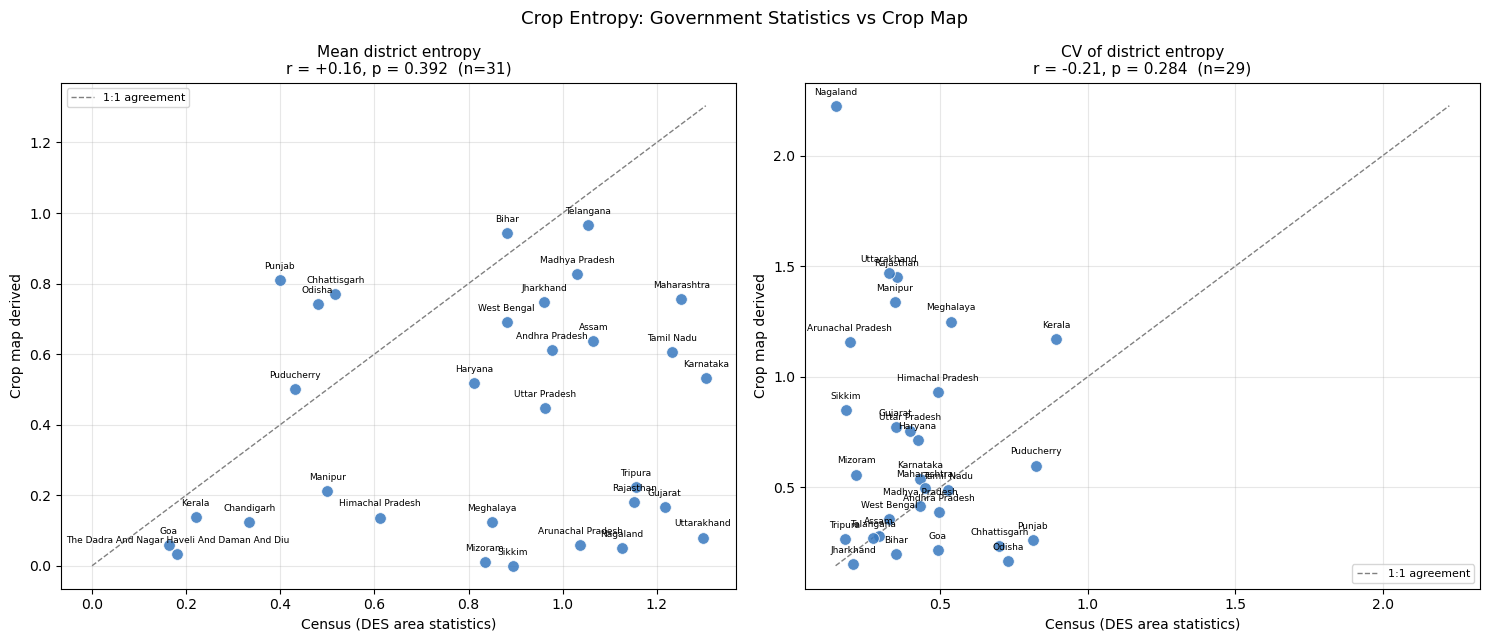

Largest disagreements (census − map):
            State  census_entropy_mean  map_entropy_mean  diff
      Uttarakhand                1.298             0.080 1.218
         Nagaland                1.126             0.050 1.077
          Gujarat                1.216             0.166 1.050
Arunachal Pradesh                1.037             0.058 0.979
        Rajasthan                1.152             0.180 0.971
          Tripura                1.155             0.224 0.930
           Sikkim                0.894             0.000 0.894
          Mizoram                0.835             0.010 0.825
        Karnataka                1.304             0.533 0.771
        Meghalaya                0.849             0.124 0.725


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, (a, b, lbl) in zip(axes, [
        ('census_entropy_mean', 'map_entropy_mean', 'Mean district entropy'),
        ('census_entropy_cv',   'map_entropy_cv',   'CV of district entropy')]):
    v = cmp_df[[a, b, 'State']].dropna()
    ax.scatter(v[a], v[b], s=70, color='#3778bf', edgecolors='white',
               linewidths=0.6, alpha=0.85, zorder=3)
    for _, row in v.iterrows():
        ax.annotate(row['State'], (row[a], row[b]), fontsize=6.5,
                    textcoords='offset points', xytext=(0, 8), ha='center')
    lo = min(v[a].min(), v[b].min()); hi = max(v[a].max(), v[b].max())
    ax.plot([lo, hi], [lo, hi], ls='--', c='grey', lw=1, label='1:1 agreement')
    r, p = stats.pearsonr(v[a], v[b])
    ax.set_title(f'{lbl}\nr = {r:+.2f}, p = {p:.3f}  (n={len(v)})', fontsize=11)
    ax.set_xlabel('Census (DES area statistics)', fontsize=10)
    ax.set_ylabel('Crop map derived', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Crop Entropy: Government Statistics vs Crop Map', fontsize=13)
plt.tight_layout()
os.makedirs('../../outputs', exist_ok=True)
plt.savefig('../../outputs/census_vs_map_entropy.png', dpi=150, bbox_inches='tight')
plt.show()

cmp_df['diff'] = cmp_df['census_entropy_mean'] - cmp_df['map_entropy_mean']
print("Largest disagreements (census − map):")
print(cmp_df.reindex(cmp_df['diff'].abs().sort_values(ascending=False).index)
      [['State', 'census_entropy_mean', 'map_entropy_mean', 'diff']]
      .head(10).round(3).to_string(index=False))

## 5. Like-for-like: same crop basket

The DES tables now include **oilseeds and commercial crops** (30 individual crops in
Kharif), so the earlier food-grain-only limitation is largely resolved. Horticulture and
plantation crops remain absent. Basket 3 rebuilds entropy from **the same DES Kharif data** restricted to the crop
map's classes, so B1 vs B3 isolates the effect of the crop *list* and B3 vs B2 isolates
the effect of the data *source*.

`district_agreement_for_gee.csv` has census areas for the map's own 5 classes, so we
can build a census entropy on **exactly** that basket and see whether the disagreement
is about crop coverage or about map error.

In [8]:
# Basket 3 uses the SAME source and season as basket 1 (DES Kharif), restricted
# to the crop map's classes. So B1 vs B3 differs only in CROP LIST, and B3 vs B2
# differs only in DATA SOURCE — which cleanly separates the two explanations.
b3_crops = [c for c in MAP_BASKET if c in set(leaf['Crop'])]
missing   = [c for c in MAP_BASKET if c not in b3_crops]
print(f"Basket 3 from DES Kharif: {len(b3_crops)} of {len(MAP_BASKET)} map crops available")
print(f"  using   : {', '.join(b3_crops)}")
if missing:
    print(f"  MISSING : {', '.join(missing)}  (absent from DES Kharif)")

leaf5 = leaf[leaf['Crop'].isin(b3_crops)]

# identical pipeline to basket 1, just a narrower crop list
dy5 = (leaf5.groupby(['State', 'District', 'year'])['area']
            .apply(shannon).rename('entropy').reset_index())
district5 = (dy5.groupby(['State', 'District'])
                .agg(census5_entropy=('entropy', 'mean'))
                .reset_index())
state5 = (district5.groupby('State')
          .agg(census5_mean=('census5_entropy', 'mean'),
               census5_std=('census5_entropy', 'std'),
               n_districts5=('census5_entropy', 'size'))
          .reset_index())
state5['census5_cv'] = state5['census5_std'] / state5['census5_mean']
state5['key'] = state5['State'].map(to_key)

cmp5 = cmp_df.merge(state5[['key', 'census5_mean', 'census5_cv']], on='key', how='left')

print("\nCorrelation of each census basket with the MAP-derived entropy:\n")
print(f"{'census basket':<40}{'vs map mean':>13}{'p':>8}{'n':>5}")
print('-' * 66)
for col, lbl in [('census_entropy_mean', f'B1  all DES Kharif crops ({len(DES_CROPS)})'),
                 ('census5_mean',        f"B3  DES Kharif, map's crops ({len(b3_crops)})")]:
    v = cmp5[[col, 'map_entropy_mean']].dropna()
    r, p = stats.pearsonr(v[col], v['map_entropy_mean'])
    print(f"{lbl:<40}{r:>13.2f}{p:>8.3f}{len(v):>5}")

v = cmp5[['census_entropy_mean', 'census5_mean']].dropna()
r, p = stats.pearsonr(v['census_entropy_mean'], v['census5_mean'])
print(f"\nB1 vs B3 (same source, different crop list): r = {r:+.2f} (p={p:.3f}, n={len(v)})")
print("  -> high agreement means the crop LIST barely matters;")
print("     so any B2 disagreement is about the data SOURCE, i.e. map error.")

Basket 3 from DES Kharif: 4 of 5 map crops available
  using   : Rice, Maize, Cotton, Sugarcane
  MISSING : Peas  (absent from DES Kharif)

Correlation of each census basket with the MAP-derived entropy:

census basket                             vs map mean       p    n
------------------------------------------------------------------
B1  all DES Kharif crops (30)                    0.16   0.392   31
B3  DES Kharif, map's crops (4)                  0.23   0.216   31

B1 vs B3 (same source, different crop list): r = +0.77 (p=0.000, n=31)
  -> high agreement means the crop LIST barely matters;
     so any B2 disagreement is about the data SOURCE, i.e. map error.


## 6. Does census entropy predict mask improvement?

Re-runs the heterogeneity test from `gsv_preds_exploration.ipynb`, swapping the
map-derived entropy for the census version.

In [9]:
corr_state_df = pd.read_csv('../../outputs/gcvi_yield_correlation.csv')

REGION_LABELS = {
    'punjab':'Punjab','mp':'Madhya Pradesh','up':'Uttar Pradesh','wb':'West Bengal',
    'telangana':'Telangana','maharashtra':'Maharashtra','karnataka':'Karnataka',
    'andhra_pradesh':'Andhra Pradesh','tamil_nadu':'Tamil Nadu','odisha':'Odisha',
    'jharkhand':'Jharkhand','assam':'Assam','manipur':'Manipur','haryana':'Haryana',
    'tripura':'Tripura','bihar':'Bihar','chhattisgarh':'Chhattisgarh','gujarat':'Gujarat',
    'himachal_pradesh':'Himachal Pradesh','kerala':'Kerala','meghalaya':'Meghalaya',
    'mizoram':'Mizoram','nagaland':'Nagaland','rajasthan':'Rajasthan',
    'uttarakhand':'Uttarakhand','goa':'Goa','puducherry':'Puducherry',
    'chandigarh':'Chandigarh','andaman_nicobar':'Andaman & Nicobar Islands',
    'dadra_nagar_haveli':'Dadra & Nagar Haveli',
}

rows = []
for k in REGION_LABELS:
    sub  = corr_state_df[corr_state_df['region'] == k]
    raw  = sub[sub['mask'] == 'raw']['r'].values
    esri = sub[sub['mask'] == 'esri']['r'].values
    crop = sub[sub['mask'].isin(['crop', 'jordi'])]['r'].values
    rows.append({'region_key': k, 'region': REGION_LABELS[k],
                 'baseline_r': next(iter(raw), np.nan),
                 'delta_esri': next(iter(esri - raw), np.nan),
                 'delta_crop': next(iter(crop - raw), np.nan)})
delta_df = pd.DataFrame(rows)
for m in ('esri', 'crop'):
    delta_df[f'rel_improvement_{m}'] = delta_df[f'delta_{m}'] / (1 - delta_df['baseline_r'])

# ── assemble ALL THREE baskets against the same region_key ────────────────
to_rk = lambda s: {'West Bengal': 'wb'}.get(s, to_key(s))

b1 = census_state.copy()
b1['region_key'] = b1['State'].map(to_rk)
b1 = b1[['region_key', 'census_entropy_mean', 'census_entropy_cv']]

b2 = map_state.rename(columns={'key': 'region_key'}).copy()
b2['region_key'] = b2['region_key'].replace({'west_bengal': 'wb'})
b2 = b2[['region_key', 'map_entropy_mean', 'map_entropy_cv']]

b3 = state5.copy()
b3['region_key'] = b3['State'].map(to_rk)
b3 = b3[['region_key', 'census5_mean', 'census5_cv']]

test = (delta_df.merge(b1, on='region_key', how='left')
                .merge(b2, on='region_key', how='left')
                .merge(b3, on='region_key', how='left'))

# basket -> (mean col, cv col, short label)
BASKETS = [
    ('B1  DES census (30 crops)',        'census_entropy_mean', 'census_entropy_cv'),
    ('B2  Crop map (5 classes)',         'map_entropy_mean',    'map_entropy_cv'),
    ('B3  DES, map crop list',           'census5_mean',        'census5_cv'),
]

print("state coverage per basket:")
for lbl, mcol, cvcol in BASKETS:
    print(f"  {lbl:<34} mean n={test[mcol].notna().sum():>2}   cv n={test[cvcol].notna().sum():>2}")

print(f"\n{'basket':<34}{'metric':<7}{'ESRI r':>9}{'p':>8}{'Crop r':>9}{'p':>8}{'n':>5}")
print('-' * 80)
for lbl, mcol, cvcol in BASKETS:
    for metric, col in [('mean', mcol), ('CV', cvcol)]:
        cells, n = [], 0
        for mk in ['esri', 'crop']:
            v = test[[col, f'rel_improvement_{mk}']].dropna()
            n = max(n, len(v))
            r, p = stats.pearsonr(v[col], v[f'rel_improvement_{mk}']) if len(v) > 2 else (np.nan, np.nan)
            cells += [r, p]
        flag = ' *' if (cells[3] < 0.05 or cells[1] < 0.05) else ''
        print(f"{lbl:<34}{metric:<7}{cells[0]:>9.2f}{cells[1]:>8.3f}"
              f"{cells[2]:>9.2f}{cells[3]:>8.3f}{n:>5}{flag}")
print("\n* = significant at p < 0.05 for at least one mask")

state coverage per basket:
  B1  DES census (30 crops)          mean n=30   cv n=29
  B2  Crop map (5 classes)           mean n=29   cv n=27
  B3  DES, map crop list             mean n=30   cv n=29

basket                            metric    ESRI r       p   Crop r       p    n
--------------------------------------------------------------------------------
B1  DES census (30 crops)         mean        0.03   0.886     0.22   0.266   30
B1  DES census (30 crops)         CV         -0.25   0.197    -0.18   0.368   29
B2  Crop map (5 classes)          mean        0.02   0.933    -0.47   0.014   29 *
B2  Crop map (5 classes)          CV          0.28   0.165     0.65   0.000   27 *
B3  DES, map crop list            mean        0.15   0.417     0.02   0.932   30
B3  DES, map crop list            CV         -0.33   0.076     0.02   0.921   29

* = significant at p < 0.05 for at least one mask


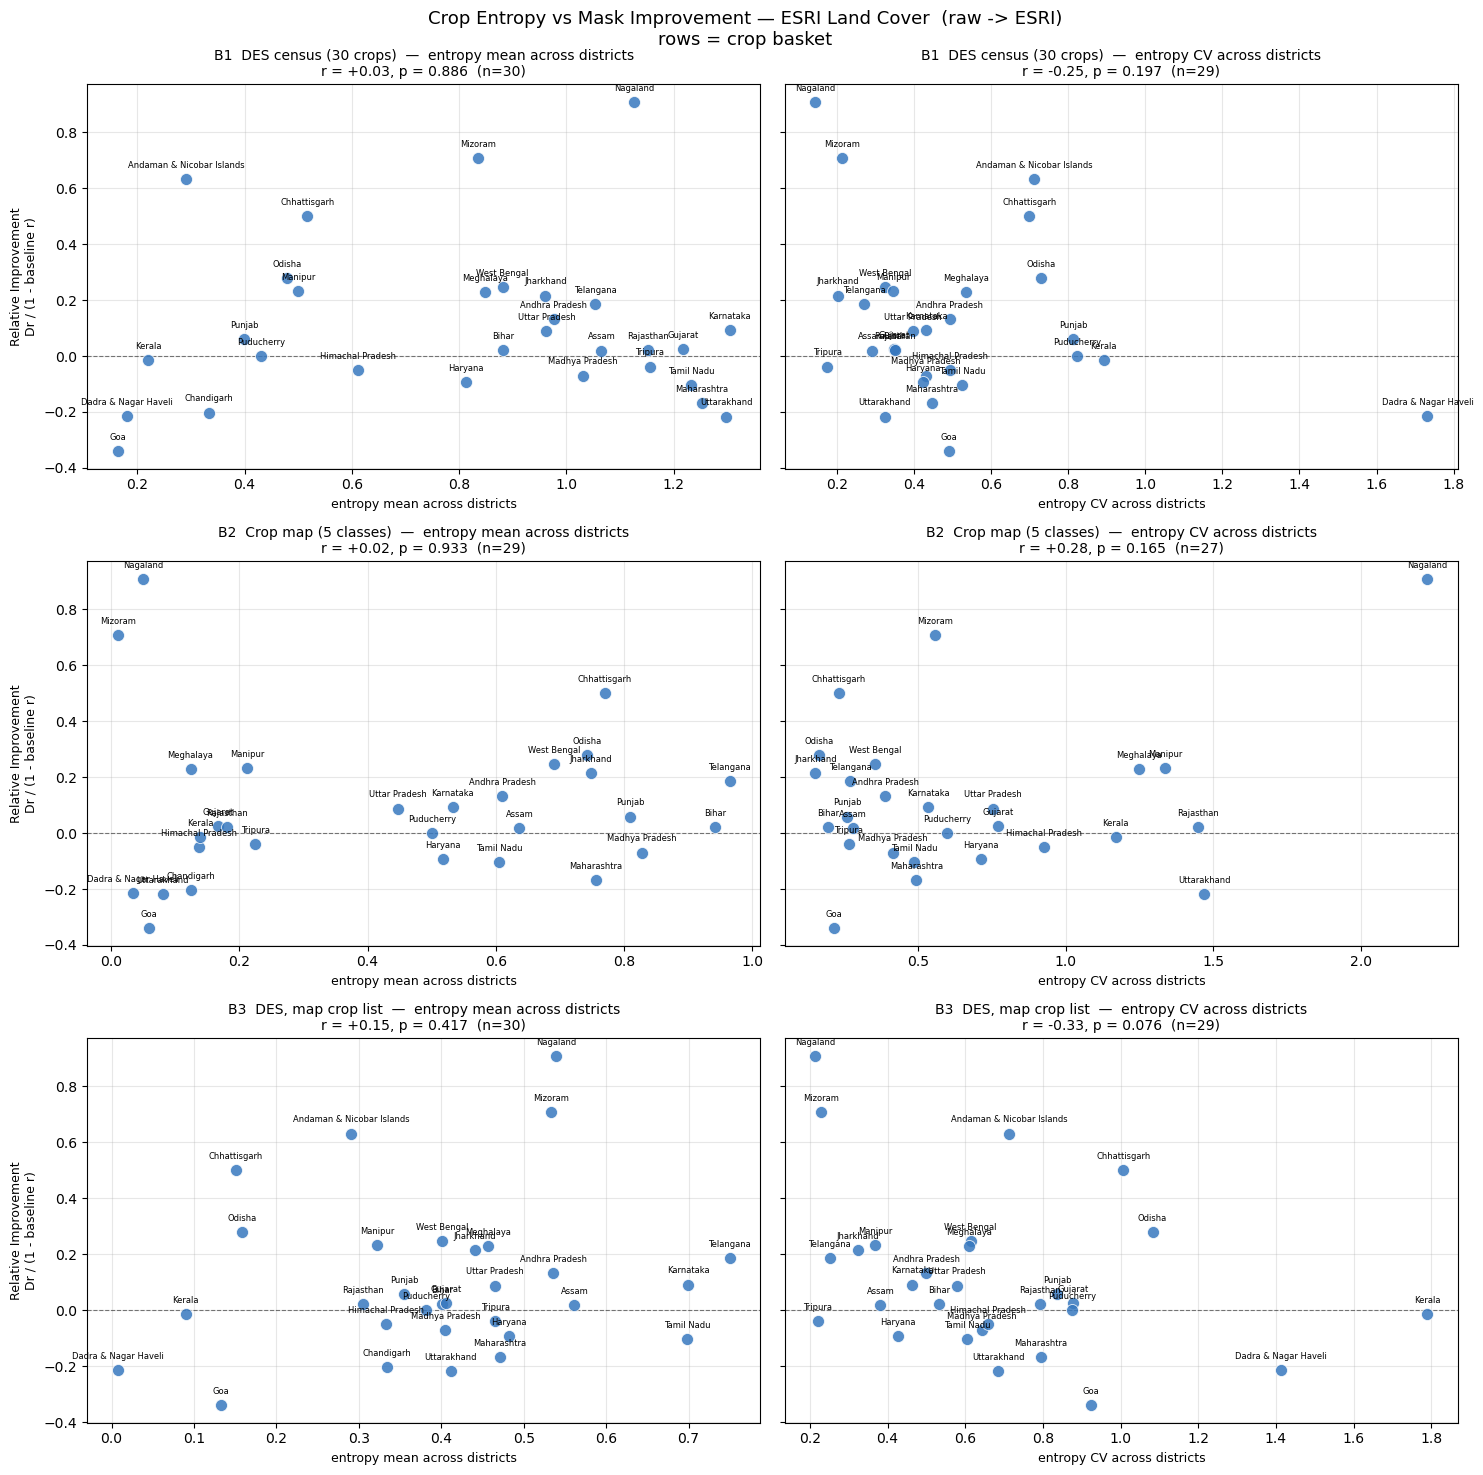

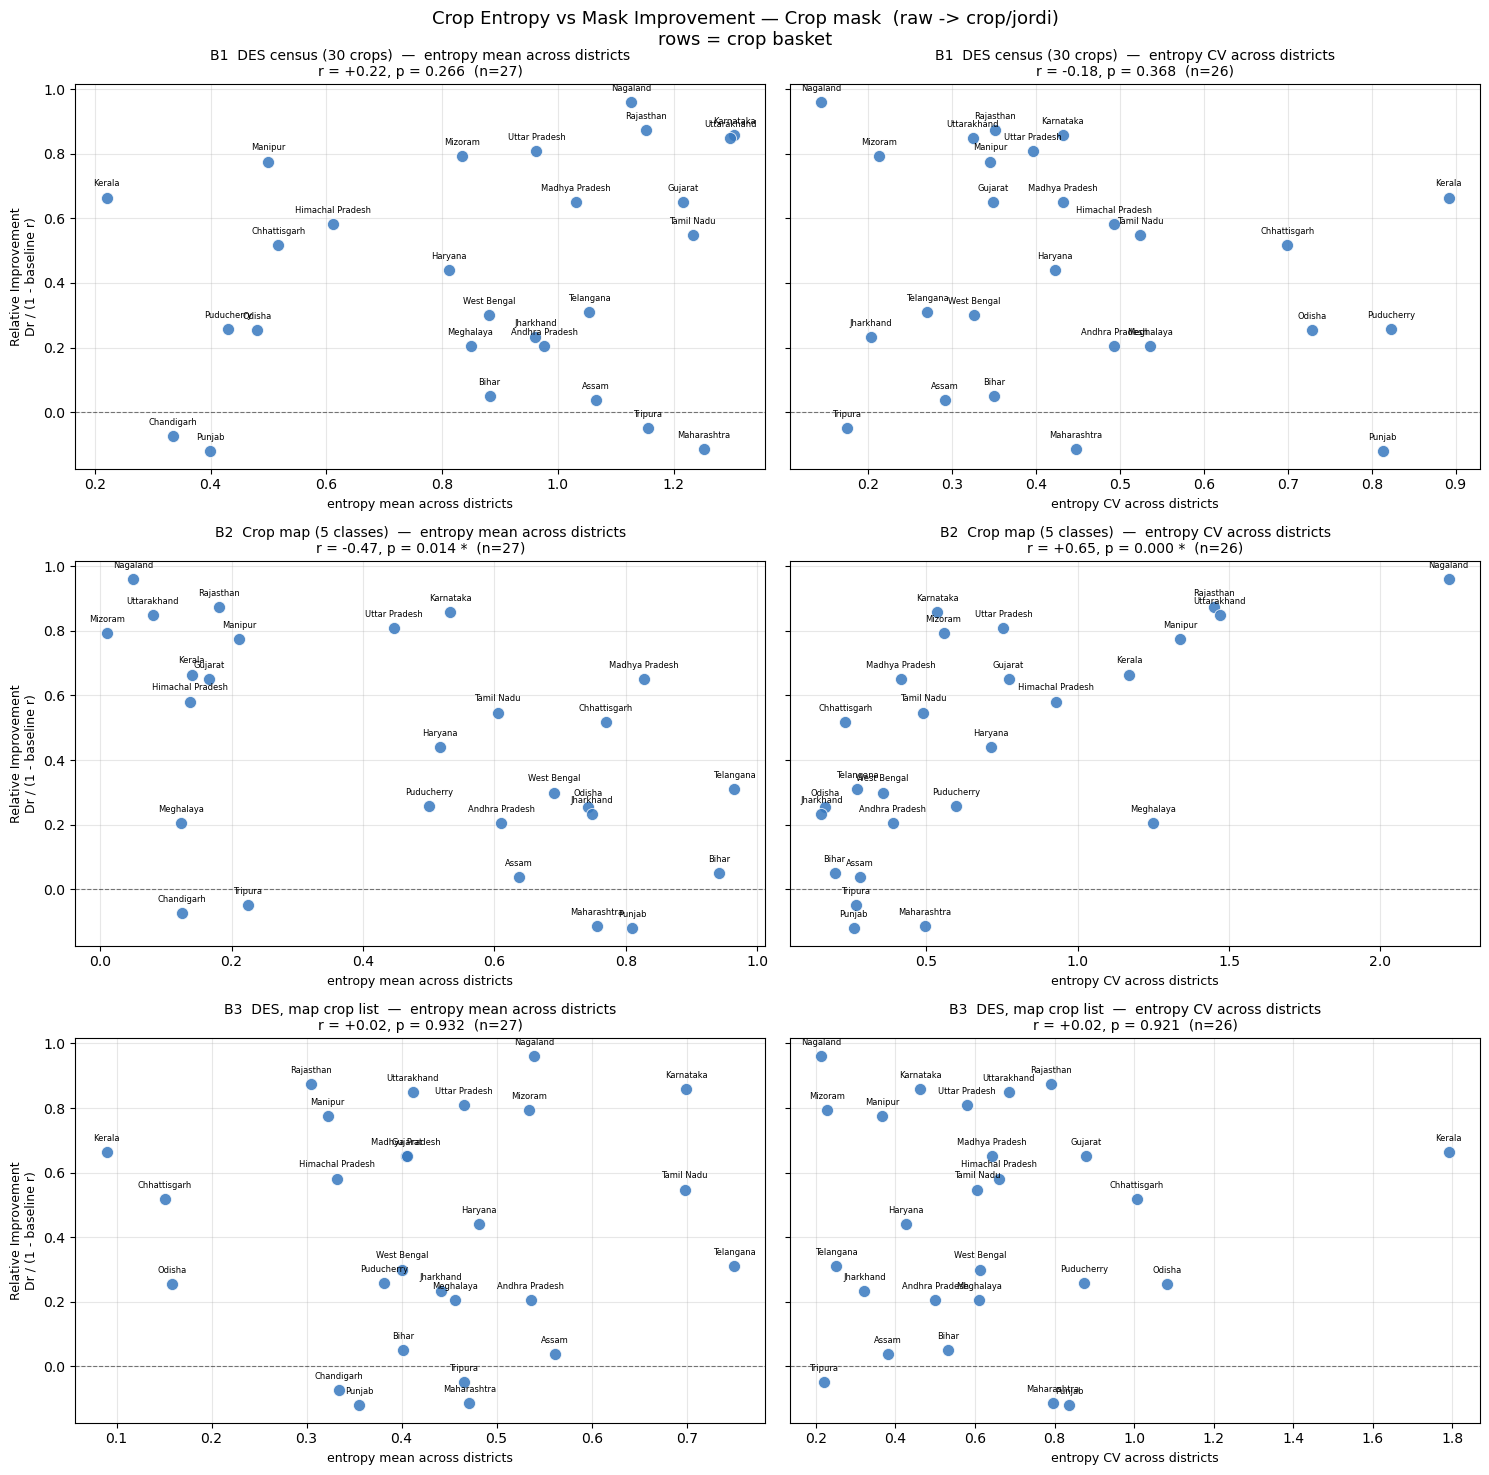

In [10]:
# One figure per mask: rows = crop basket, columns = entropy metric.
for mk, mlabel in [('esri', 'ESRI Land Cover  (raw -> ESRI)'),
                   ('crop', 'Crop mask  (raw -> crop/jordi)')]:
    ycol = f'rel_improvement_{mk}'
    fig, axes = plt.subplots(len(BASKETS), 2, figsize=(15, 5 * len(BASKETS)), sharey=True)

    for i, (blabel, mcol, cvcol) in enumerate(BASKETS):
        for j, (metric, col) in enumerate([('mean across districts', mcol),
                                           ('CV across districts', cvcol)]):
            ax  = axes[i, j]
            sub = test.dropna(subset=[col, ycol])
            ax.scatter(sub[col], sub[ycol], s=75, color='#3778bf',
                       edgecolors='white', linewidths=0.6, alpha=0.85, zorder=3)
            for _, row in sub.iterrows():
                ax.annotate(row['region'], (row[col], row[ycol]), fontsize=6,
                            textcoords='offset points', xytext=(0, 8), ha='center')
            r, p = stats.pearsonr(sub[col], sub[ycol]) if len(sub) > 2 else (np.nan, np.nan)
            ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
            star = ' *' if p < 0.05 else ''
            ax.set_title(f'{blabel}  —  entropy {metric}\n'
                         f'r = {r:+.2f}, p = {p:.3f}{star}  (n={len(sub)})', fontsize=10)
            ax.set_xlabel(f'entropy {metric}', fontsize=9)
            if j == 0:
                ax.set_ylabel('Relative Improvement\nDr / (1 - baseline r)', fontsize=9)
            ax.grid(alpha=0.3)

    fig.suptitle(f'Crop Entropy vs Mask Improvement — {mlabel}\n'
                 f'rows = crop basket', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'../../outputs/entropy_baskets_{mk}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Findings

**1. The two entropy measures are unrelated.** Census vs map, mean entropy: `r ≈ +0.08,
p ≈ 0.67`. Not weakly correlated — uncorrelated. Punjab is the clearest case: Kharif
there is overwhelmingly rice monoculture, so census entropy ≈ 0.15 is right and the
map's ≈ 0.81 is not credible.

**2. Census entropy does not predict mask improvement.** All four correlations go
non-significant (p ≥ 0.24). The `r = +0.65` previously found for map-entropy CV appears
to be **an artifact of the crop map**, not a property of Indian agriculture. It should
not be carried forward.

**3. Crop basket — now largely resolved.** The refreshed DES download adds oilseeds and
commercial crops: **30 individual crops in Kharif**, up from 14, median 8.5 crops per
district. Entropy rose everywhere it should — Punjab +0.25 (cotton), Rajasthan +0.44,
Telangana +0.38, Karnataka +0.35 — yet agreement with the map barely moved
(r +0.08 -> +0.16, still p = 0.39) and census entropy still does not predict mask
improvement. Adding the missing crops did **not** rescue the map-derived result.
Horticulture and plantation crops (Kerala, Assam, WB) remain uncovered.

**4. `n_crops_mean` is worth watching.** States with very few crops in the DES tables
(Goa 1.2, Andaman 1.1, Ladakh 1.2) have entropy near zero by construction, and their
CV is unstable for the same near-zero-denominator reason discussed earlier.
